<p>
<img src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" width="170">
</p>
<p>
<h1><b><center>Astroestadistica</center></b></h1>
<h2><b><center>Prof. Juan Carlos Muñoz</center></b></h1>
<h2><b><center>Parcial 3</center></b><h2>
<h3><b><center></center></b><h3>
<h5><center><b>Asignada</b>: 27 de Noviembre de 2023</center><h5>
<h5><center><b>Entrega</b>: 29 de Noviembre de 2023</center><h5>
</p>

<hr/>
<b>Nombre</b>: Alejandro Murillo Orrego
<br/>
<b>Cédula</b>:1000748606
<br/>
<b>Última actualización</b>:12 de septiembre
<hr/>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import random
from scipy import integrate
import scipy.integrate as integrate

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
datos = pd.read_csv("/content/drive/MyDrive/AstroEstadistica/Rotcurve_con_errores.dat", delimiter="\s+", header=None)

In [ ]:
Ri = datos.iloc[1:,0]
Vci= datos.iloc[1:,1]
error = datos.iloc[1:,2]

In [ ]:
#Constantes
G = 43007.1
a = 7
b = 0.5

#Unidades
UM=1e10 #Msun
UL=1 #Kpc
UT=1.1 #Gyr
UV=1 #km/s

def M(R,Md,Mh,rs):
  Vcd = G*Md*R/((R**2 + (a+b)**2)**(3/2))
  Vch = G*Mh*R/((R + rs)**2)
  return (Vch + Vcd)**0.5



In [ ]:
Md_p,Mh_p,Rs_p=2.1760113058575605, 1.7935905272002048, 0.8783819964569629

In [ ]:
def posterior(md,mh,rs):
  post = np.ones(len(Ri)+2)

  epsilon = Vci - M(Ri, md, mh, rs)

  for i in range(1, len(Ri)+1):
        post[i+1] =  post[i]*(1/(2*np.pi*error[i]**2)**0.5)*np.exp((-epsilon[i]**2)/(2*error[i]**2))

  return post[-1]

posterior(Md_p,Mh_p,Rs_p)

0.0

### Probabilidades marginalizadas

In [ ]:
mda = 1e9/UM
mdb = 1e11/UM
mha = 1e10/UM
mhb = 1e12/UM
rsa = 1/UL
rsb = 50/UL

mha, mhb, rsa, rsb

(1.0, 100.0, 1.0, 50.0)

In [ ]:
def prob_md(md):
  N = 5000
  mha = 1e10/UM
  mhb = 1e12/UM
  rsa = 1/UL
  rsb = 50/UL

  integral = 0.0
  #sigma = 0.0

  for i in range(N):
      mh = random.uniform(mha, mhb)
      rs = random.uniform(rsa, rsb)
      fi = posterior(md, mh, rs)
      integral += fi
      #sigma += fi*fi

  integral = integral/(N)
  #sigma = sigma/(1.0*NSAMPLES)
  #variance = sigma - integral*integral
  #stdd = np.sqrt(variance)
  return integral


In [ ]:
from tqdm import tqdm


md_x = np.linspace(0,50, 100)
probmd = np.zeros(len(md_x))

for i in tqdm(range(0, 100), desc='Calculando probmd'):
    probmd[i] = prob_md(md_x[i])


Calculando probmd: 100%|██████████| 100/100 [08:38<00:00,  5.18s/it]


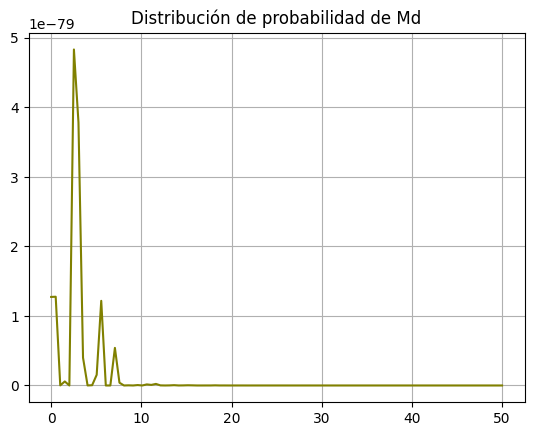

In [ ]:
plt.plot(md_x, probmd, color='olive')
plt.title('Distribución de probabilidad de Md')
plt.grid()

#### probabilidad mh

In [ ]:
def prob_mh(mh):
  N = 2000
  mda = 1e9/UM
  mdb = 1e11/UM
  #mha = 1e10/UM
  #mhb = 1e12/UM
  rsa = 1/UL
  rsb = 50/UL

  integral = 0.0
  #sigma = 0.0

  for i in range(N):
      md = random.uniform(mda, mdb)
      rs = random.uniform(rsa, rsb)
      fi = posterior(md, mh, rs)
      integral += fi
      #sigma += fi*fi

  integral = integral/(N)
  #sigma = sigma/(1.0*NSAMPLES)
  #variance = sigma - integral*integral
  #stdd = np.sqrt(variance)
  return integral

In [ ]:
mh_x = np.linspace(15, 25, 100)
probmh = np.zeros(len(mh_x))

for i in tqdm(range(0, 100), desc='Calculando probmh'):
    probmh[i] = prob_mh(mh_x[i])

Calculando probmh: 100%|██████████| 100/100 [03:27<00:00,  2.08s/it]


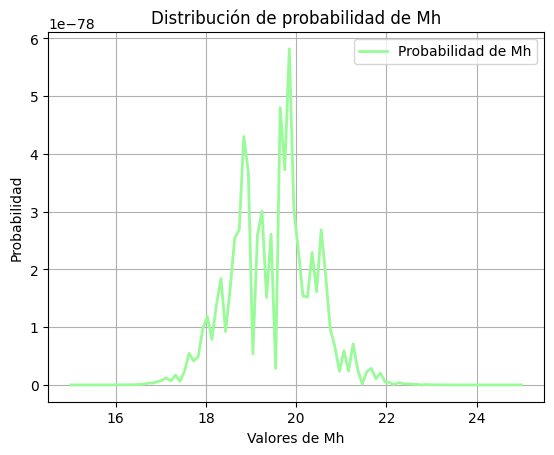

In [ ]:

plt.plot(mh_x, probmh, color='palegreen', linewidth=2, label='Probabilidad de Mh')
plt.xlabel('Valores de Mh')
plt.ylabel('Probabilidad')
plt.title('Distribución de probabilidad de Mh')
plt.legend()
plt.grid()


plt.show()

#### probabilidad rs

In [ ]:
def prob_rs(rs):
  N = 2000
  mda = 1e9/UM
  mdb = 1e11/UM
  mha = 1e10/UM
  mhb = 1e12/UM
  #rsa = 1/UL
  #rsb = 50/UL

  integral = 0.0
  #sigma = 0.0

  for i in range(N):
      md = random.uniform(mda, mdb)
      mh = random.uniform(mha, mhb)
      fi = posterior(md, mh, rs)
      integral += fi
      #sigma += fi*fi

  integral = integral/(N)
  #sigma = sigma/(1.0*NSAMPLES)
  #variance = sigma - integral*integral
  #stdd = np.sqrt(variance)
  return integral

In [ ]:
rs_x = np.linspace(2, 8, 200)
probrs = np.zeros(len(rs_x))

for i in tqdm(range(0, 200), desc='Calculando probrs'):
    probrs[i] = prob_rs(rs_x[i])

Calculando probrs: 100%|██████████| 200/200 [07:15<00:00,  2.18s/it]


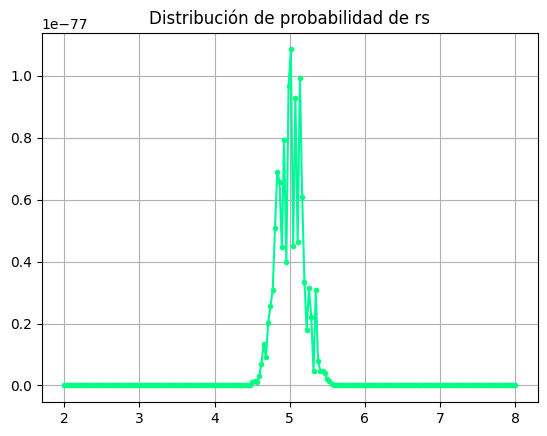

In [ ]:
plt.plot(rs_x, probrs, color='mediumspringgreen')
plt.plot(rs_x, probrs, '.', color='springgreen')
plt.title('Distribución de probabilidad de rs')

plt.grid()

In [ ]:
np.std(probmd), np.std(probmh), np.std(probrs)

(2.123923779552049e-79, 1.203307139202463e-78, 1.848804163340125e-78)

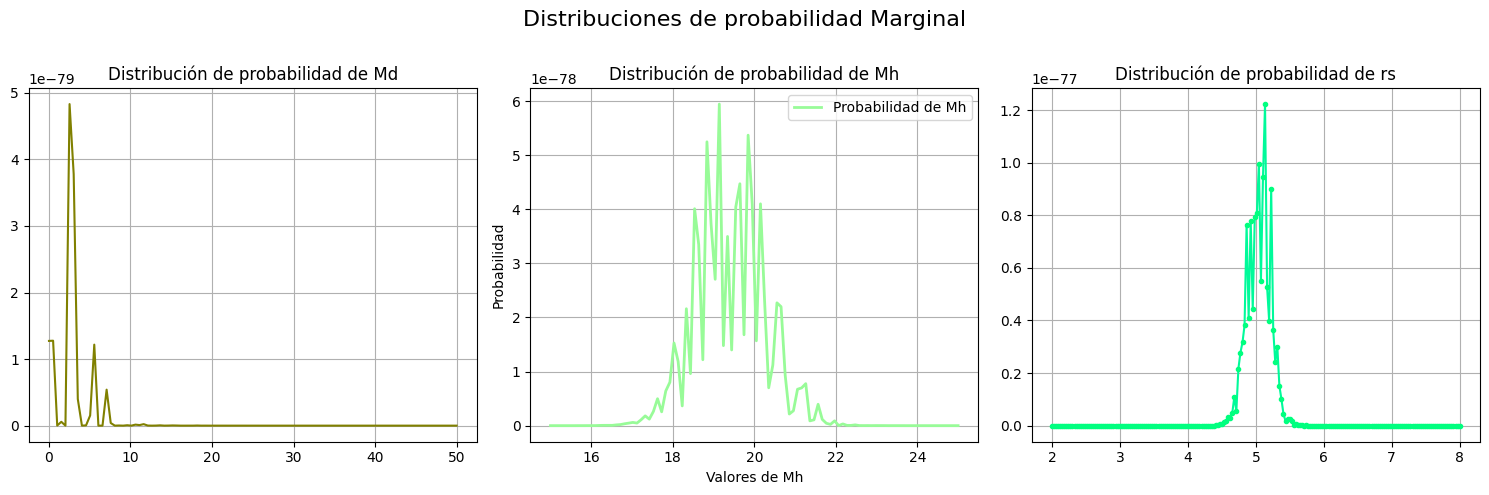

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1 - Distribución de probabilidad de Md
ax[0].plot(md_x, probmd, color='olive')
ax[0].set_title('Distribución de probabilidad de Md')
ax[0].grid()

# Gráfico 2 - Distribución de probabilidad de Mh
ax[1].plot(mh_x, probmh, color='palegreen', linewidth=2, label='Probabilidad de Mh')
ax[1].set_xlabel('Valores de Mh')
ax[1].set_ylabel('Probabilidad')
ax[1].set_title('Distribución de probabilidad de Mh')
ax[1].legend()
ax[1].grid()

# Gráfico 3 - Distribución de probabilidad de rs
ax[2].plot(rs_x, probrs, color='mediumspringgreen')
ax[2].plot(rs_x, probrs, '.', color='springgreen')
ax[2].set_title('Distribución de probabilidad de rs')
ax[2].grid()

# Título para el conjunto de subplots
fig.suptitle('Distribuciones de probabilidad Marginal', fontsize=16)

plt.tight_layout()
plt.show()